# Understanding the Learnable CWT Layer

This notebook walks through `ContinuousCWTLayer` step by step, building intuition
for each stage with concrete examples and visualizations.

The layer applies [complex Morlet wavelets](https://en.wikipedia.org/wiki/Morlet_wavelet)
at **learnable** center frequencies to decompose a 1-D signal into a 2-D
time–frequency map, then resamples the time axis to a fixed token count.

**Four stages:**
1. Learnable parameter construction (softplus reparameterization)
2. Morlet wavelet construction (Gaussian envelope × oscillation)
3. FFT-based convolution (efficient cross-correlation)
4. Grid-sample time resampling + magnitude/phase extraction

In [ ]:
import math
import sys
sys.path.insert(0, "..")

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

from foundry.models.embeddings.temporal.cwt import ContinuousCWTLayer

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.3})
torch.manual_seed(42);

/home/nvidia/Foundry/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-24 15:46:28,092	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


## Synthetic test signal

A chirp (frequency sweep from 2 Hz to 20 Hz) plus a brief 10 Hz burst starting at
t = 1.5 s. This gives us something with clear time-varying frequency content.

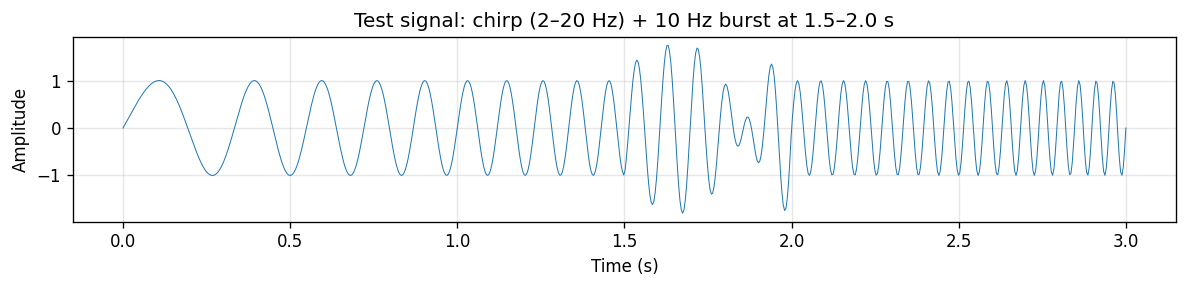

In [2]:
FS = 256.0
DURATION = 3.0
N = int(FS * DURATION)
t_sec = torch.linspace(0, DURATION, N)

# Linear chirp: instantaneous freq goes from 2 Hz to 20 Hz
f0, f1 = 2.0, 20.0
chirp_phase = 2 * math.pi * (f0 * t_sec + 0.5 * (f1 - f0) / DURATION * t_sec**2)
chirp = torch.sin(chirp_phase)

# 10 Hz burst between 1.5s and 2.0s
burst_mask = ((t_sec >= 1.5) & (t_sec <= 2.0)).float()
burst = 0.8 * torch.sin(2 * math.pi * 10 * t_sec) * burst_mask

signal = chirp + burst

fig, ax = plt.subplots(figsize=(10, 2.5))
ax.plot(t_sec.numpy(), signal.numpy(), lw=0.6)
ax.set(xlabel="Time (s)", ylabel="Amplitude", title="Test signal: chirp (2–20 Hz) + 10 Hz burst at 1.5–2.0 s")
plt.tight_layout()

---
## 1. Learnable Parameters & Softplus Reparameterization

The layer has two sets of learnable parameters: **center frequencies** and
**cycle counts** (`n_cycles`). Both must stay positive during training, so the
layer stores *unconstrained* values and maps them through
`softplus(x) = log(1 + eˣ)` plus a minimum floor.

At init the inverse softplus is applied so that the constrained values start
exactly at the user-specified initial values.

> **Reference:** [Softplus activation – PyTorch docs](https://pytorch.org/docs/stable/generated/torch.nn.functional.softplus.html)

Unconstrained params (raw):    [ 1.738  4.893  9.9   14.9   19.9  ]
Constrained freqs (Hz):        [ 2.  5. 10. 15. 20.]
Constrained n_cycles:          [7. 7. 7. 7. 7.]


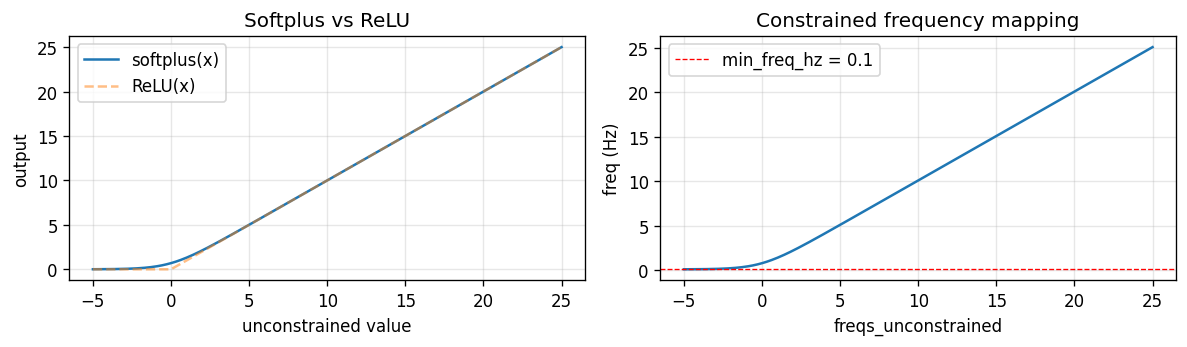

In [3]:
init_freqs = [2.0, 5.0, 10.0, 15.0, 20.0]
layer = ContinuousCWTLayer(init_freqs=init_freqs, target_time_tokens=64, n_cycles=7.0)

print("Unconstrained params (raw):   ", layer.freqs_unconstrained.data.numpy().round(3))
print("Constrained freqs (Hz):       ", layer.freqs.detach().numpy().round(3))
print("Constrained n_cycles:         ", layer.n_cycles.detach().numpy().round(3))

# Show the softplus mapping
x = torch.linspace(-5, 25, 300)
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

axes[0].plot(x.numpy(), F.softplus(x).numpy(), label="softplus(x)")
axes[0].plot(x.numpy(), torch.relu(x).numpy(), "--", alpha=0.5, label="ReLU(x)")
axes[0].set(xlabel="unconstrained value", ylabel="output", title="Softplus vs ReLU")
axes[0].legend()

min_f = layer.min_freq_hz
axes[1].plot(x.numpy(), (min_f + F.softplus(x)).numpy())
axes[1].axhline(min_f, color="r", ls="--", lw=0.8, label=f"min_freq_hz = {min_f}")
axes[1].set(xlabel="freqs_unconstrained", ylabel="freq (Hz)", title="Constrained frequency mapping")
axes[1].legend()
plt.tight_layout()

Softplus is smooth everywhere (unlike ReLU), strictly positive, and approximately
linear for large inputs. Gradient descent can move `freqs_unconstrained` freely
over the entire real line while the actual frequency stays above `min_freq_hz`.

---
## 2. Morlet Wavelet Construction

A [Morlet wavelet](https://en.wikipedia.org/wiki/Morlet_wavelet) is a complex
sinusoid windowed by a Gaussian envelope:

$$\psi(t) = \exp\!\left(-\frac{t^2}{2\sigma^2}\right) \cdot e^{\,i\,2\pi f\, t}$$

The Gaussian width is $\sigma = \frac{n_{\text{cycles}}}{2\pi f}$, tying it
to both the frequency and the **time–frequency trade-off** parameter `n_cycles`:

- **More cycles** → wider wavelet → sharper frequency resolution, blurrier time resolution
- **Fewer cycles** → narrower wavelet → sharper time resolution, blurrier frequency resolution

This is a manifestation of the [Heisenberg uncertainty principle for signal processing](https://en.wikipedia.org/wiki/Uncertainty_principle#Signal_processing).

Let's reproduce the construction step by step.

In [4]:
# --- Reproduce wavelet construction from forward() ---
with torch.no_grad():
    fs_val = torch.tensor([FS])
    Max_T = N
    F_dim = len(init_freqs)

    f = layer.freqs.view(1, F_dim, 1)
    n_c = layer.n_cycles.view(1, F_dim, 1)

    K = Max_T if Max_T % 2 != 0 else Max_T + 1
    t_samples = torch.arange(-(K // 2), K // 2 + 1).float()
    t_wav = t_samples.view(1, 1, K) / fs_val.view(1, 1, 1)  # -> seconds

    sigma = n_c / (2 * math.pi * f)
    envelope = torch.exp((-(t_wav**2) / (2 * sigma**2)).clamp(min=-60.0))

    real_wavelet = torch.cos(2 * math.pi * f * t_wav) * envelope
    imag_wavelet = torch.sin(2 * math.pi * f * t_wav) * envelope

    norm_factor = envelope.sum(dim=-1, keepdim=True) + 1e-8
    real_wavelet /= norm_factor
    imag_wavelet /= norm_factor

print(f"Wavelet kernel shape: {real_wavelet.shape}  (B, F_dim, K)")
print(f"Kernel length K = {K} samples  ({K / FS:.2f} s)")

Wavelet kernel shape: torch.Size([1, 5, 769])  (B, F_dim, K)
Kernel length K = 769 samples  (3.00 s)


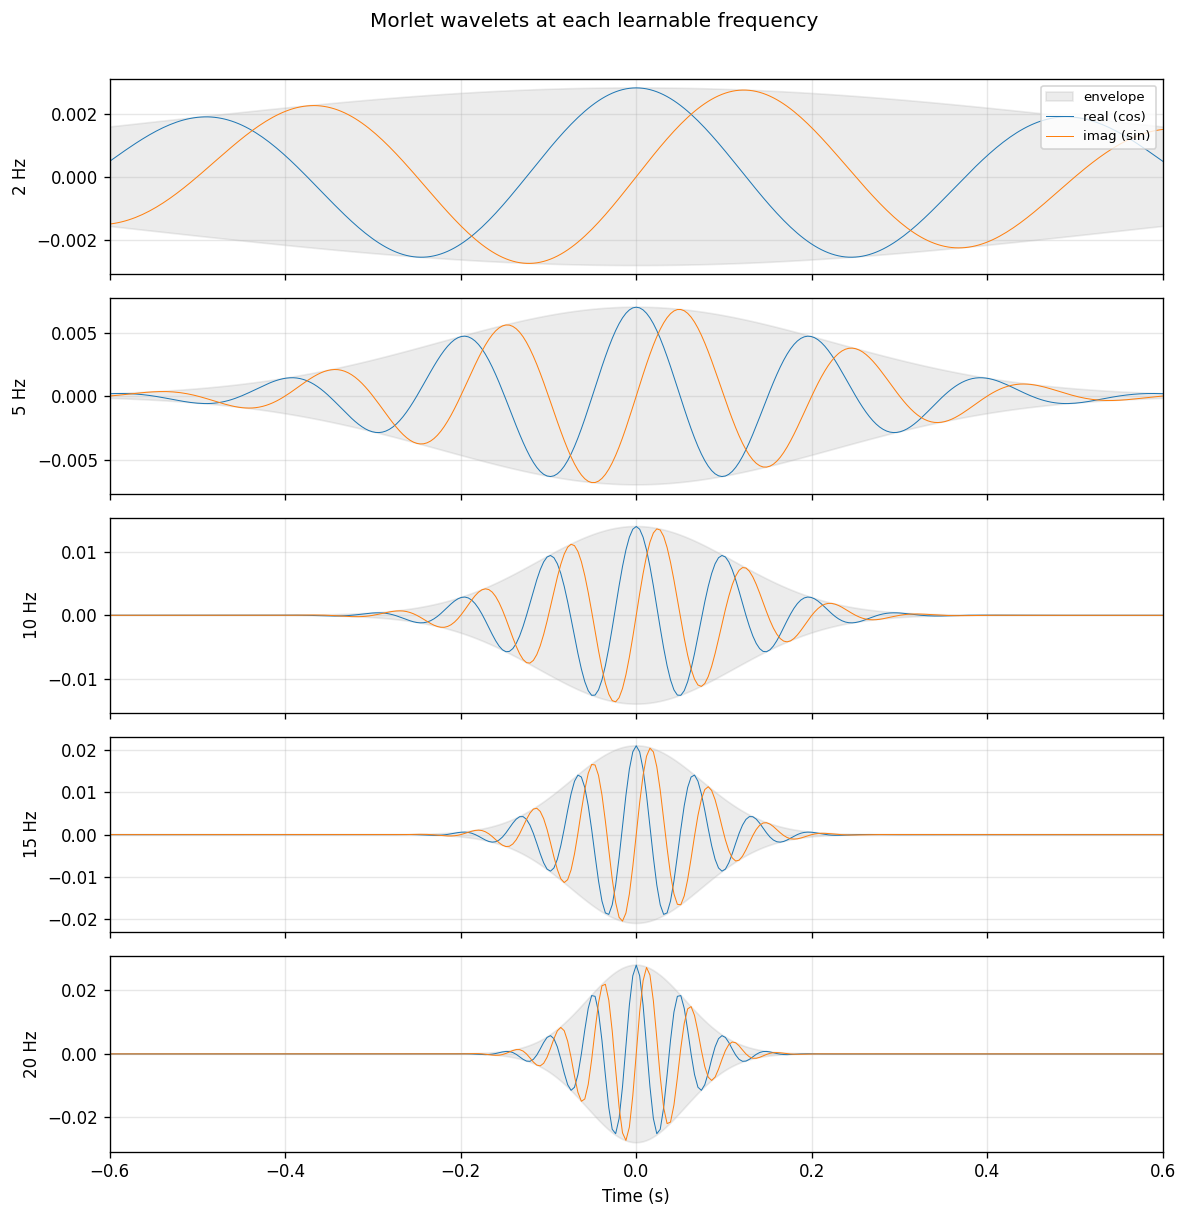

In [5]:
# Visualize wavelets: envelope, real part, imaginary part
t_plot = t_samples.numpy() / FS

fig, axes = plt.subplots(F_dim, 1, figsize=(10, 2.0 * F_dim), sharex=True)
for i, ax in enumerate(axes):
    env_i = (envelope[0, i] / norm_factor[0, i]).numpy()
    re_i = real_wavelet[0, i].numpy()
    im_i = imag_wavelet[0, i].numpy()

    ax.fill_between(t_plot, -env_i, env_i, alpha=0.15, color="gray", label="envelope")
    ax.plot(t_plot, re_i, lw=0.6, label="real (cos)")
    ax.plot(t_plot, im_i, lw=0.6, label="imag (sin)")

    freq_hz = layer.freqs[i].item()
    sig_s = sigma[0, i, 0].item()
    ax.set_ylabel(f"{freq_hz:.0f} Hz")
    ax.set_xlim(-0.6, 0.6)
    if i == 0:
        ax.legend(loc="upper right", fontsize=8)

axes[-1].set_xlabel("Time (s)")
fig.suptitle("Morlet wavelets at each learnable frequency", y=1.01)
plt.tight_layout()

Notice how **higher-frequency wavelets are narrower** (the Gaussian shrinks as
$\sigma \propto 1/f$), while lower-frequency wavelets are wider and contain
slower oscillations. The `n_cycles` parameter controls how many oscillation
cycles fit within the Gaussian — here all wavelets share the same initial value of 7.

---
## 3. FFT-Based Convolution

We need to **slide each wavelet across the signal** and measure similarity at
every time point. This is a cross-correlation, which is computed efficiently via:

1. FFT both signal and (flipped) wavelet
2. Pointwise multiply in the frequency domain
3. Inverse FFT

This works because convolution in time = multiplication in frequency (the
[convolution theorem](https://en.wikipedia.org/wiki/Convolution_theorem)).
The kernel is flipped first so that FFT-convolution yields cross-correlation
instead (correct phase alignment).

In [6]:
with torch.no_grad():
    x_in = signal.unsqueeze(0).unsqueeze(0)  # (1, 1, N)

    kernel_real = real_wavelet.flip(-1)  # (1, F_dim, K)
    kernel_imag = imag_wavelet.flip(-1)
    full_len = Max_T + K - 1
    n_fft = 1 << (full_len - 1).bit_length()

    x_fft = torch.fft.rfft(x_in, n=n_fft, dim=-1)            # (1, 1, n_fft//2+1)
    real_fft = torch.fft.rfft(kernel_real, n=n_fft, dim=-1)   # (1, F_dim, n_fft//2+1)
    imag_fft = torch.fft.rfft(kernel_imag, n=n_fft, dim=-1)

    out_real_full = torch.fft.irfft(
        x_fft.unsqueeze(2) * real_fft.unsqueeze(1), n=n_fft, dim=-1
    )[..., :full_len]
    out_imag_full = torch.fft.irfft(
        x_fft.unsqueeze(2) * imag_fft.unsqueeze(1), n=n_fft, dim=-1
    )[..., :full_len]

    start = K // 2
    end = start + Max_T
    out_real = out_real_full[..., start:end]  # (1, 1, F_dim, Max_T)
    out_imag = out_imag_full[..., start:end]

    mag = torch.sqrt(out_real.square() + out_imag.square() + 1e-8)

print(f"Convolution output shape: {out_real.shape}  (B, C, F_dim, Max_T)")

Convolution output shape: torch.Size([1, 1, 5, 768])  (B, C, F_dim, Max_T)


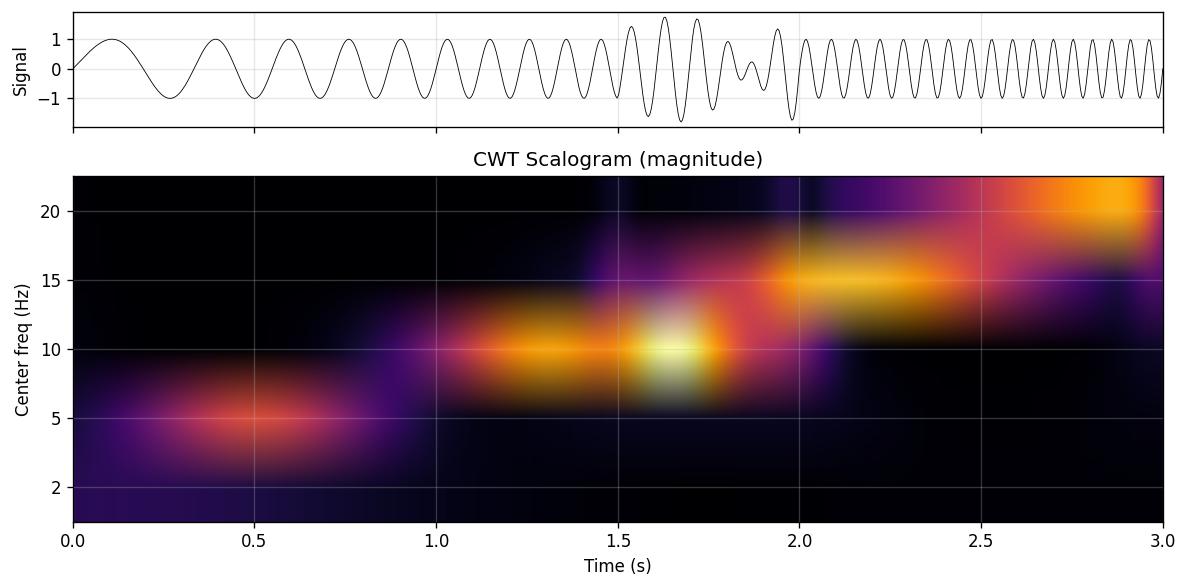

In [17]:
# Visualize the raw scalogram (magnitude of CWT coefficients)
fig, axes = plt.subplots(2, 1, figsize=(10, 5), gridspec_kw={"height_ratios": [1, 3]})

axes[0].plot(t_sec.numpy(), signal.numpy(), lw=0.5, color="k")
axes[0].set(ylabel="Signal", xlim=(0, DURATION))
axes[0].set_xticklabels([])

mag_np = mag[0, 0].numpy()  # (F_dim, Max_T)
time_axis = t_sec.numpy()
freq_labels = [f"{layer.freqs[i].item():.0f}" for i in range(F_dim)]

im = axes[1].imshow(
    mag_np, aspect="auto", origin="lower",
    extent=[0, DURATION, -0.5, F_dim - 0.5],
    interpolation="bilinear", cmap="inferno",
)
axes[1].set_yticks(range(F_dim))
axes[1].set_yticklabels(freq_labels)
axes[1].set(xlabel="Time (s)", ylabel="Center freq (Hz)", title="CWT Scalogram (magnitude)")
# plt.colorbar(im, ax=axes[1], label="Magnitude")
plt.tight_layout()

The scalogram shows that each wavelet picks up energy where its frequency
is present in the signal. The chirp traces a diagonal (rising frequency
over time), and the 10 Hz burst appears as a bright spot at 1.5–2.0 s.

---
## 4. Time Resampling via `grid_sample`

Signals in a batch can have different lengths (zero-padded to `Max_T`).
The layer resamples each signal's time axis to a fixed `target_time_tokens`
count using [`grid_sample`](https://pytorch.org/docs/stable/generated/torch.nn.functional.grid_sample.html),
which performs differentiable bilinear interpolation.

The time–frequency map is treated as a 2-D image (height = frequency bins,
width = time samples), and per-batch-item sampling coordinates are built so
that only the *valid* (non-padded) portion of each signal is covered.

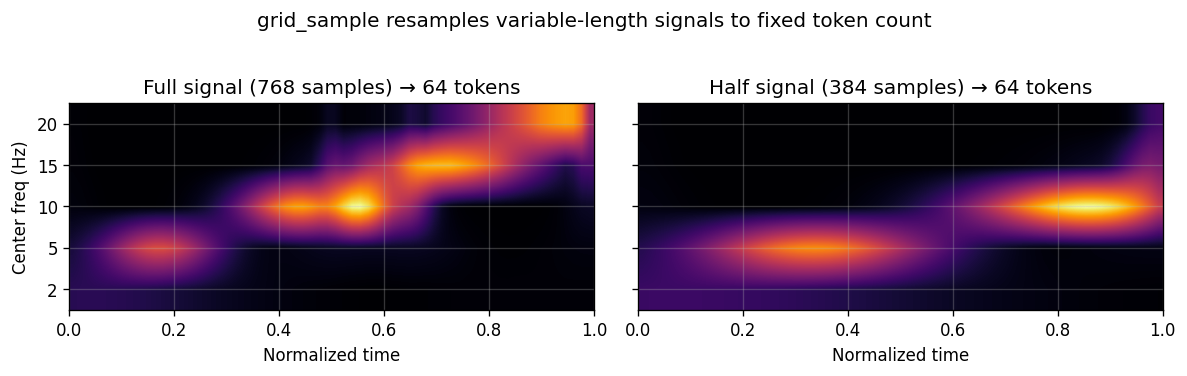

In [8]:
# Demonstrate resampling: same signal, two different valid lengths
with torch.no_grad():
    target_T = layer.target_time_tokens
    padded = torch.zeros(2, 1, Max_T)

    # Item 0: full signal
    padded[0, 0, :N] = signal
    seq_lens_demo = torch.tensor([N, N // 2])  # item 1 is half length
    # Item 1: first half of signal
    padded[1, 0, :N // 2] = signal[:N // 2]

    fs_batch = torch.tensor([FS, FS])

    out = layer(padded, fs_batch, seq_lens_demo)  # (2, 1, 2, F_dim, target_T)
    mag_full = out[0, 0, 0].numpy()    # magnitude, item 0
    mag_half = out[1, 0, 0].numpy()    # magnitude, item 1

fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=True)
for ax, data, title in [
    (axes[0], mag_full, f"Full signal ({N} samples) \u2192 {target_T} tokens"),
    (axes[1], mag_half, f"Half signal ({N//2} samples) \u2192 {target_T} tokens"),
]:
    ax.imshow(data, aspect="auto", origin="lower", cmap="inferno",
              extent=[0, 1, -0.5, F_dim - 0.5], interpolation="bilinear")
    ax.set_yticks(range(F_dim))
    ax.set_yticklabels(freq_labels)
    ax.set(xlabel="Normalized time", title=title)

axes[0].set_ylabel("Center freq (Hz)")
fig.suptitle("grid_sample resamples variable-length signals to fixed token count", y=1.03)
plt.tight_layout()

Both outputs have exactly `target_time_tokens` columns, but each covers only
its signal's true duration. The half-length signal's scalogram is stretched
to fill the same output width — it only shows content up to ~1.5 s.

---
## 5. Magnitude & Phase Extraction

The complex (real + imaginary) CWT output is converted to polar form:

- **Magnitude** $= \sqrt{\text{re}^2 + \text{im}^2}$ — *how much* of each frequency is present
- **Phase** $= \text{atan2}(\text{im}, \text{re}) / \pi$ — *where* in the oscillation cycle

Phase is suppressed for near-zero magnitudes via a soft mask
$w = |z|^2 / (|z|^2 + \epsilon)$, avoiding undefined gradients when no
frequency content is present.

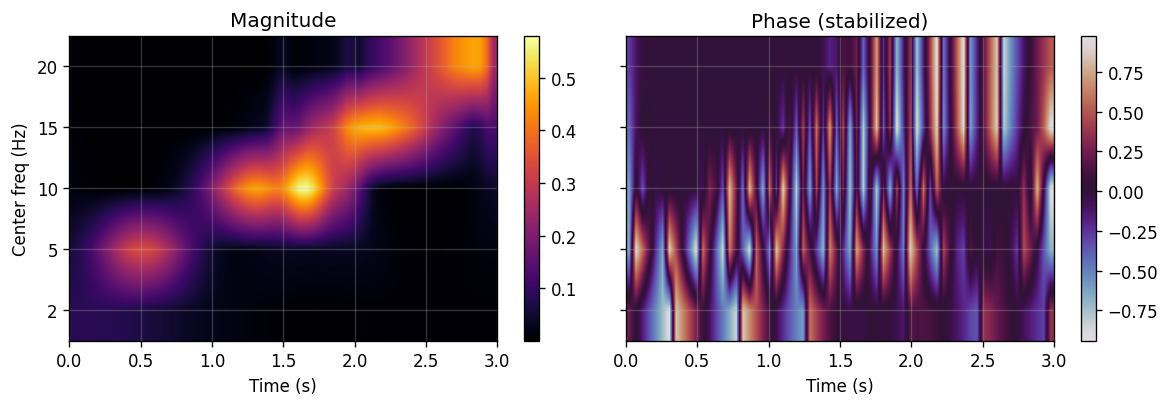

In [9]:
with torch.no_grad():
    x_single = signal.unsqueeze(0).unsqueeze(0)  # (1, 1, N)
    fs_single = torch.tensor([FS])
    seq_single = torch.tensor([N])
    full_out = layer(x_single, fs_single, seq_single)  # (1, 1, 2, F_dim, T)

    out_mag = full_out[0, 0, 0].numpy()    # (F_dim, T)
    out_phase = full_out[0, 0, 1].numpy()  # (F_dim, T)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)
for ax, data, title, cmap in [
    (axes[0], out_mag, "Magnitude", "inferno"),
    (axes[1], out_phase, "Phase (stabilized)", "twilight"),
]:
    im = ax.imshow(data, aspect="auto", origin="lower", cmap=cmap,
                   extent=[0, DURATION, -0.5, F_dim - 0.5], interpolation="bilinear")
    ax.set_yticks(range(F_dim))
    ax.set_yticklabels(freq_labels)
    ax.set(xlabel="Time (s)", title=title)
    plt.colorbar(im, ax=ax)

axes[0].set_ylabel("Center freq (Hz)")
plt.tight_layout()

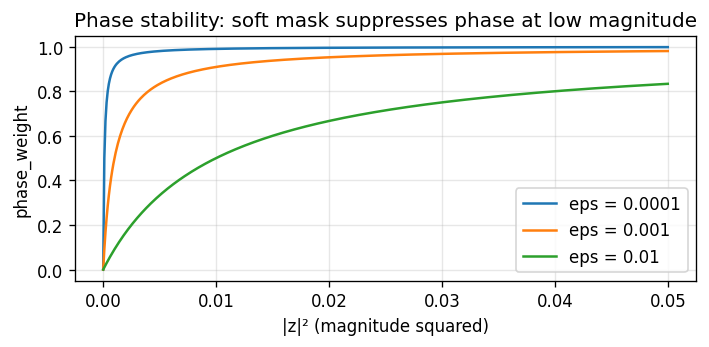

In [10]:
# Visualize the phase stability mechanism
mag_sq = torch.linspace(0, 0.05, 500)
eps_values = [1e-4, 1e-3, 1e-2]

fig, ax = plt.subplots(figsize=(6, 3))
for eps in eps_values:
    weight = mag_sq / (mag_sq + eps)
    ax.plot(mag_sq.numpy(), weight.numpy(), label=f"eps = {eps}")

ax.set(xlabel="|z|² (magnitude squared)", ylabel="phase_weight",
       title="Phase stability: soft mask suppresses phase at low magnitude")
ax.legend()
plt.tight_layout()

Where magnitude is large, `phase_weight ≈ 1` and phase passes through
unchanged. Where magnitude is near zero (no real signal), the phase is
smoothly driven toward zero, preventing noisy gradients.

---
## 6. Sampling-Frequency Invariance

A key property of this layer is that the **same physical signal sampled at
different rates produces (approximately) the same output**. This is because:

1. Wavelet frequencies are in **Hz** (physical units), not samples
2. The time axis `t_sec = t_samples / fs` converts sample indices to seconds
3. `grid_sample` resamples to a fixed token count based on valid signal duration

Let's verify this with the same 3 s signal sampled at 128 Hz, 256 Hz, and 512 Hz.

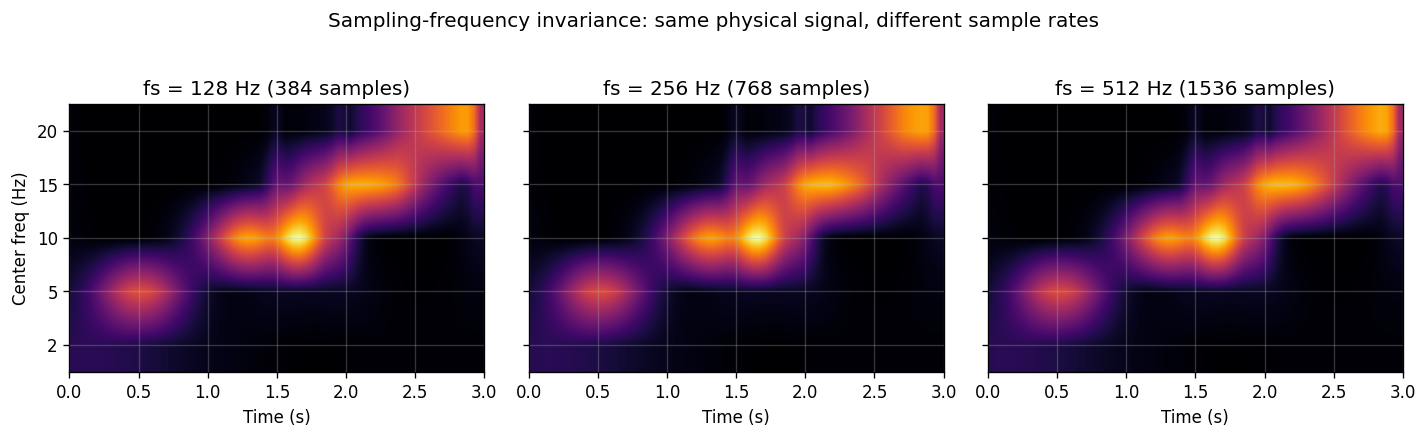

In [11]:
def make_signal_at_fs(fs_hz, duration=3.0):
    n = int(fs_hz * duration)
    t = torch.linspace(0, duration, n)
    f0, f1 = 2.0, 20.0
    chirp_phase = 2 * math.pi * (f0 * t + 0.5 * (f1 - f0) / duration * t**2)
    sig = torch.sin(chirp_phase)
    burst_mask = ((t >= 1.5) & (t <= 2.0)).float()
    sig = sig + 0.8 * torch.sin(2 * math.pi * 10 * t) * burst_mask
    return sig, n

sample_rates = [128.0, 256.0, 512.0]
max_n = max(int(fs * 3.0) for fs in sample_rates)

# Pad all to the longest and batch them
B = len(sample_rates)
x_batch = torch.zeros(B, 1, max_n)
fs_batch = torch.zeros(B)
lens_batch = torch.zeros(B, dtype=torch.long)

for i, fs_hz in enumerate(sample_rates):
    sig_i, n_i = make_signal_at_fs(fs_hz)
    x_batch[i, 0, :n_i] = sig_i
    fs_batch[i] = fs_hz
    lens_batch[i] = n_i

with torch.no_grad():
    # Need a fresh layer since max_n may differ
    layer_inv = ContinuousCWTLayer(init_freqs=init_freqs, target_time_tokens=64, n_cycles=7.0)
    out_batch = layer_inv(x_batch, fs_batch, lens_batch)  # (3, 1, 2, F, 64)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=True)
for i, (ax, fs_hz) in enumerate(zip(axes, sample_rates)):
    mag_i = out_batch[i, 0, 0].numpy()
    ax.imshow(mag_i, aspect="auto", origin="lower", cmap="inferno",
              extent=[0, 3.0, -0.5, F_dim - 0.5], interpolation="bilinear")
    ax.set_yticks(range(F_dim))
    ax.set_yticklabels(freq_labels)
    ax.set(xlabel="Time (s)", title=f"fs = {fs_hz:.0f} Hz ({lens_batch[i]} samples)")

axes[0].set_ylabel("Center freq (Hz)")
fig.suptitle("Sampling-frequency invariance: same physical signal, different sample rates", y=1.03)
plt.tight_layout()

In [12]:
# Quantitative comparison: normalized correlation between outputs at different fs
def cosine_sim(a, b):
    a_flat, b_flat = a.flatten(), b.flatten()
    return (a_flat @ b_flat / (a_flat.norm() * b_flat.norm() + 1e-12)).item()

mag_128 = out_batch[0, 0, 0]
mag_256 = out_batch[1, 0, 0]
mag_512 = out_batch[2, 0, 0]

print(f"Cosine similarity (128 Hz vs 256 Hz): {cosine_sim(mag_128, mag_256):.6f}")
print(f"Cosine similarity (256 Hz vs 512 Hz): {cosine_sim(mag_256, mag_512):.6f}")
print(f"Cosine similarity (128 Hz vs 512 Hz): {cosine_sim(mag_128, mag_512):.6f}")

Cosine similarity (128 Hz vs 256 Hz): 0.999675
Cosine similarity (256 Hz vs 512 Hz): 0.999977
Cosine similarity (128 Hz vs 512 Hz): 0.999593


The scalograms are near-identical across sample rates. Small differences come
from discretization (more samples = finer approximation of the continuous
wavelet), but the representation is fundamentally **anchored in physical
units (Hz and seconds)**, not sample counts.

---
## 7. Frequencies Extracted Are Explained by Parameters

Each wavelet acts as a **bandpass filter** centered at its learnable frequency.
Let's verify this by feeding in pure sine waves at known frequencies and
checking which wavelet responds most strongly.

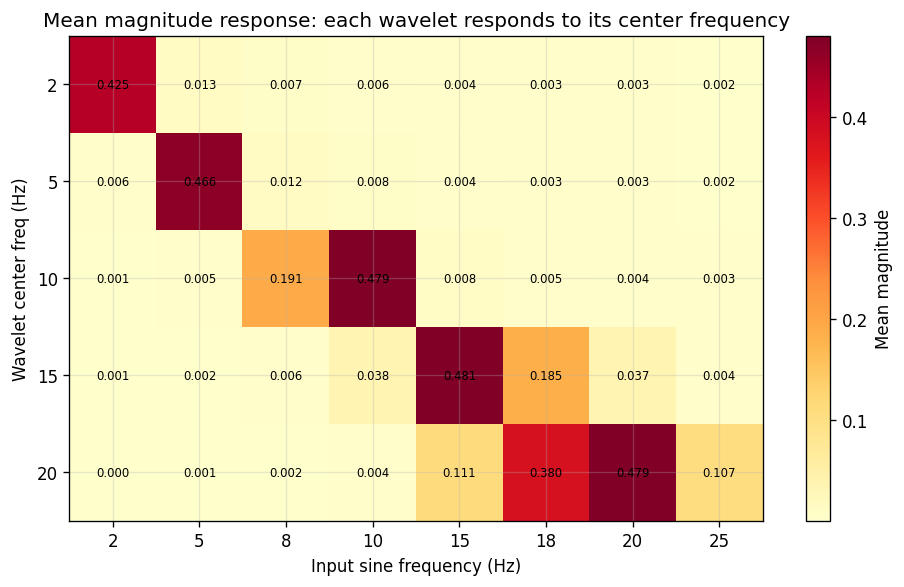

In [13]:
test_freqs_hz = [2.0, 5.0, 8.0, 10.0, 15.0, 18.0, 20.0, 25.0]
layer_test = ContinuousCWTLayer(init_freqs=init_freqs, target_time_tokens=64, n_cycles=7.0)

wavelet_freqs = layer_test.freqs.detach().numpy()
responses = np.zeros((len(test_freqs_hz), len(init_freqs)))

with torch.no_grad():
    for j, test_f in enumerate(test_freqs_hz):
        t_test = torch.linspace(0, 3.0, int(FS * 3))
        pure_tone = torch.sin(2 * math.pi * test_f * t_test)
        x_test = pure_tone.unsqueeze(0).unsqueeze(0)
        out_test = layer_test(
            x_test, torch.tensor([FS]), torch.tensor([len(t_test)])
        )
        mean_mag = out_test[0, 0, 0].mean(dim=-1).numpy()  # (F_dim,)
        responses[j] = mean_mag

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(responses.T, aspect="auto", cmap="YlOrRd", interpolation="nearest")
ax.set_xticks(range(len(test_freqs_hz)))
ax.set_xticklabels([f"{f:.0f}" for f in test_freqs_hz])
ax.set_yticks(range(len(init_freqs)))
ax.set_yticklabels([f"{f:.0f}" for f in wavelet_freqs])
ax.set(xlabel="Input sine frequency (Hz)", ylabel="Wavelet center freq (Hz)",
       title="Mean magnitude response: each wavelet responds to its center frequency")
plt.colorbar(im, ax=ax, label="Mean magnitude")

for j in range(len(test_freqs_hz)):
    for i in range(len(init_freqs)):
        ax.text(j, i, f"{responses[j, i]:.3f}", ha="center", va="center", fontsize=7)

plt.tight_layout()

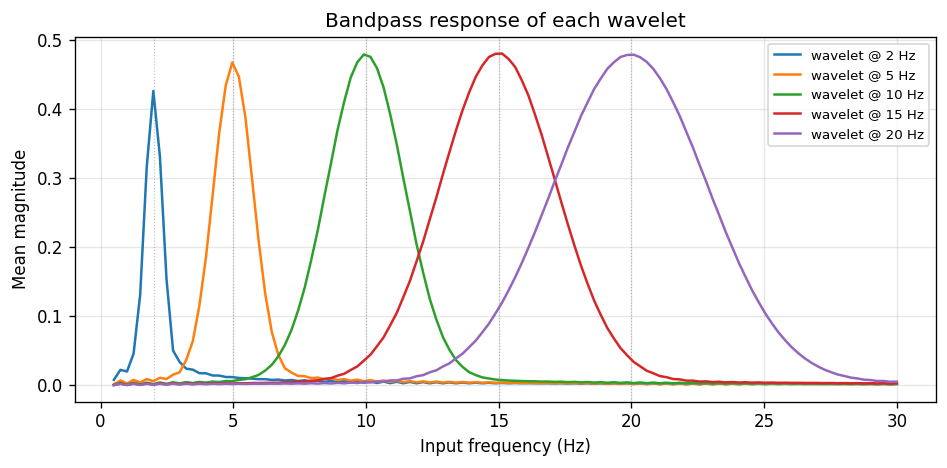

In [14]:
# Frequency response curves: sweep a fine grid of input frequencies
sweep_freqs = np.linspace(0.5, 30.0, 120)
sweep_responses = np.zeros((len(sweep_freqs), len(init_freqs)))

with torch.no_grad():
    for j, sf in enumerate(sweep_freqs):
        t_sw = torch.linspace(0, 3.0, int(FS * 3))
        tone = torch.sin(2 * math.pi * sf * t_sw).unsqueeze(0).unsqueeze(0)
        out_sw = layer_test(
            tone, torch.tensor([FS]), torch.tensor([len(t_sw)])
        )
        sweep_responses[j] = out_sw[0, 0, 0].mean(dim=-1).numpy()

fig, ax = plt.subplots(figsize=(8, 4))
for i in range(len(init_freqs)):
    ax.plot(sweep_freqs, sweep_responses[:, i], label=f"wavelet @ {wavelet_freqs[i]:.0f} Hz")
    ax.axvline(wavelet_freqs[i], color="gray", ls=":", lw=0.7, alpha=0.5)

ax.set(xlabel="Input frequency (Hz)", ylabel="Mean magnitude",
       title="Bandpass response of each wavelet")
ax.legend(fontsize=8)
plt.tight_layout()

Each wavelet acts as a bandpass filter peaked at its center frequency.
The bandwidth (how selective each wavelet is) depends on `n_cycles`:
more cycles = narrower bandwidth = more selective.

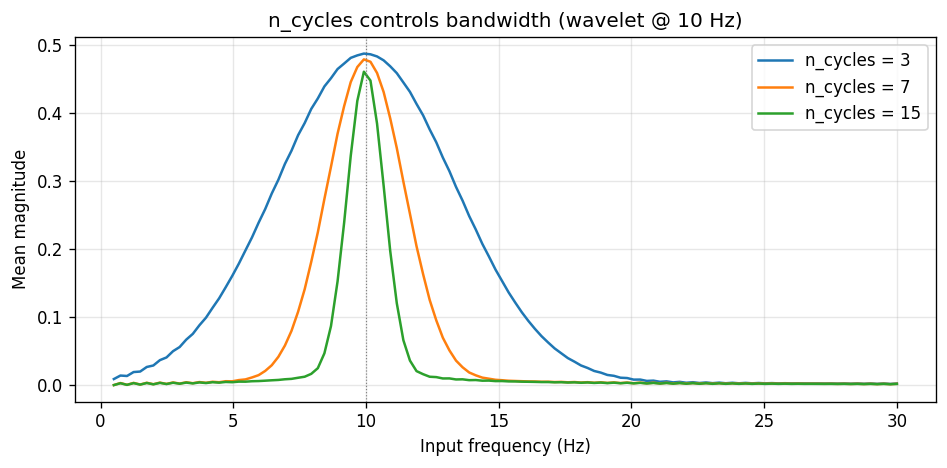

In [15]:
# Effect of n_cycles on bandwidth
fig, ax = plt.subplots(figsize=(8, 4))

for nc in [3.0, 7.0, 15.0]:
    layer_nc = ContinuousCWTLayer(init_freqs=[10.0], target_time_tokens=64, n_cycles=nc)
    resp_nc = np.zeros(len(sweep_freqs))
    with torch.no_grad():
        for j, sf in enumerate(sweep_freqs):
            t_sw = torch.linspace(0, 3.0, int(FS * 3))
            tone = torch.sin(2 * math.pi * sf * t_sw).unsqueeze(0).unsqueeze(0)
            out_nc = layer_nc(
                tone, torch.tensor([FS]), torch.tensor([len(t_sw)])
            )
            resp_nc[j] = out_nc[0, 0, 0].mean(dim=-1).item()
    ax.plot(sweep_freqs, resp_nc, label=f"n_cycles = {nc:.0f}")

ax.axvline(10.0, color="gray", ls=":", lw=0.7)
ax.set(xlabel="Input frequency (Hz)", ylabel="Mean magnitude",
       title="n_cycles controls bandwidth (wavelet @ 10 Hz)")
ax.legend()
plt.tight_layout()

---
## Summary

| Stage | What happens | Key idea |
|-------|-------------|----------|
| **Parameters** | `softplus` maps unconstrained params → positive Hz / cycles | Differentiable constraint |
| **Wavelets** | Gaussian × sinusoid at each frequency | Time–frequency trade-off via `n_cycles` |
| **FFT conv** | Slide wavelets across signal in O(N log N) | Convolution theorem |
| **Resample** | `grid_sample` → fixed token count per signal | Handles variable lengths |
| **Mag/Phase** | Polar decomposition + phase stabilization | Stable, interpretable features |

The layer is **sampling-rate invariant** because wavelets are defined in
physical units (Hz, seconds). The extracted frequencies are fully explained
by `init_freqs`, and the selectivity by `n_cycles` — both of which the
network can learn to adjust during training.

### Further reading

- [Morlet wavelet (Wikipedia)](https://en.wikipedia.org/wiki/Morlet_wavelet)
- [Continuous wavelet transform (Wikipedia)](https://en.wikipedia.org/wiki/Continuous_wavelet_transform)
- [Convolution theorem](https://en.wikipedia.org/wiki/Convolution_theorem)
- [Heisenberg uncertainty in signal processing](https://en.wikipedia.org/wiki/Uncertainty_principle#Signal_processing)
- [PyTorch `grid_sample`](https://pytorch.org/docs/stable/generated/torch.nn.functional.grid_sample.html)